# Análisis de tecnologías de la información: Población

## Cargando librerías y el conjunto de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet('datos/respondents.parquet')
df.head()

,ResponseId,LanguageHaveWorkedWith,LanguageWantToWorkWith,LanguageAdmired,DatabaseHaveWorkedWith,DatabaseWantToWorkWith,DatabaseAdmired,PlatformHaveWorkedWith,PlatformWantToWorkWith,PlatformAdmired,NEWCollabToolsHaveWorkedWith,NEWCollabToolsWantToWorkWith,NEWCollabToolsAdmired,YearsCode,YearsCodePro,Country,EdLevel_Group,Age_Group,RemoteWork_Clean
0,2,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Dynamodb;MongoDB;PostgreSQL,PostgreSQL,PostgreSQL,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,Amazon Web Services (AWS);Heroku;Netlify,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,PyCharm;Visual Studio Code;WebStorm,20.0,17.0,GBR,Undergraduate Degree,35-44,Remote
1,3,C#,C#,C#,Firebase Realtime Database,Firebase Realtime Database,Firebase Realtime Database,Google Cloud,Google Cloud,Google Cloud,Visual Studio,Visual Studio,Visual Studio,37.0,27.0,GBR,Postgraduate Degree,45-54,Remote
2,4,C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...,MongoDB;MySQL;PostgreSQL;SQLite,MongoDB;MySQL;PostgreSQL,MongoDB;MySQL;PostgreSQL,Amazon Web Services (AWS);Fly.io;Heroku,Amazon Web Services (AWS);Vercel,Amazon Web Services (AWS),None,None,None,4.0,NaN,CAN,No Formal Degree,18-24,Not specified
3,5,C++;HTML/CSS;JavaScript;Lua;Python;Rust,C++;HTML/CSS;JavaScript;Lua;Python,C++;HTML/CSS;JavaScript;Lua;Python,PostgreSQL;SQLite,PostgreSQL;SQLite,PostgreSQL;SQLite,None,None,None,Vim,Vim,Vim,9.0,NaN,NOR,No Formal Degree,18-24,Not specified
4,6,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,Bash/Shell (all shells);HTML/CSS;Java;JavaScri...,Cloud Firestore,Cloud Firestore,Cloud Firestore,Cloudflare,Cloudflare,Cloudflare,Nano;Vim;Visual Studio Code;Xcode,Nano;Vim;Visual Studio Code;Xcode,Nano;Vim;Visual Studio Code;Xcode,10.0,NaN,USA,No Formal Degree,Under 18,Not specified


## Tamaño de la muestra

In [3]:
df.shape

(60059, 19)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60059 entries, 0 to 60058
Data columns (total 19 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ResponseId                    60059 non-null  int64  
 1   LanguageHaveWorkedWith        59745 non-null  object 
 2   LanguageWantToWorkWith        55752 non-null  object 
 3   LanguageAdmired               50872 non-null  object 
 4   DatabaseHaveWorkedWith        50254 non-null  object 
 5   DatabaseWantToWorkWith        42558 non-null  object 
 6   DatabaseAdmired               38557 non-null  object 
 7   PlatformHaveWorkedWith        42366 non-null  object 
 8   PlatformWantToWorkWith        34532 non-null  object 
 9   PlatformAdmired               31377 non-null  object 
 10  NEWCollabToolsHaveWorkedWith  57592 non-null  object 
 11  NEWCollabToolsWantToWorkWith  52087 non-null  object 
 12  NEWCollabToolsAdmired         50711 non-null  object 
 13  Y

## Distribucion de experiencia

In [5]:
df["YearsCodePro"].dropna().describe()

count    50054.000000
mean        10.288508
std          9.102448
min          0.500000
25%          3.000000
50%          8.000000
75%         15.000000
max         51.000000
Name: YearsCodePro, dtype: float64

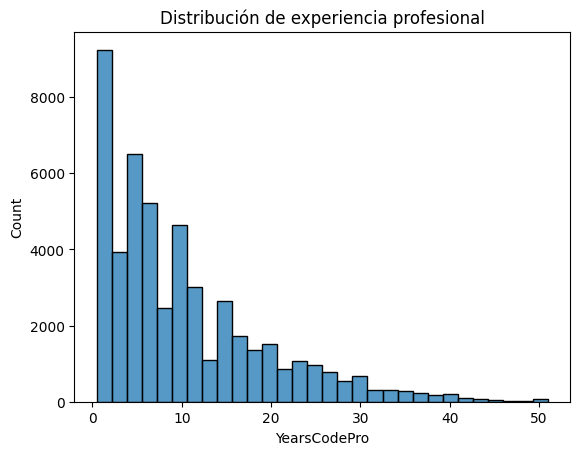

In [6]:
sns.histplot(df["YearsCodePro"], bins=30)
plt.title("Distribución de experiencia profesional")
plt.show()

La distribucion muestra asimetría positiva, dominada por desarrolladores junior y de nivel medio, estos resultados reflejan profesionales activos en desarrollo profesional mas que decisiones tecnologicas de perfiles altamente experimentados

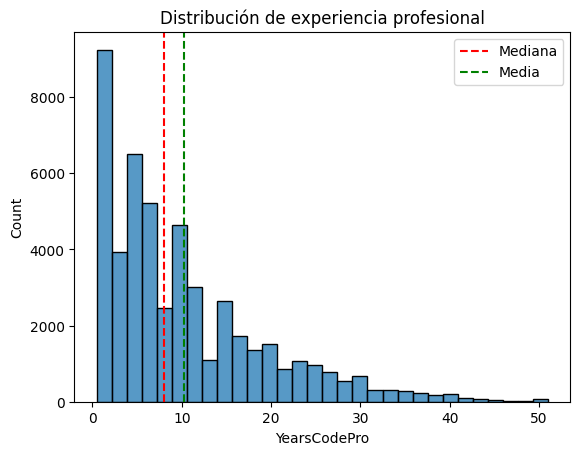

In [7]:
sns.histplot(df['YearsCodePro'], bins=30)
plt.axvline(df['YearsCodePro'].median(), color = 'red', linestyle = '--', label = 'Mediana')
plt.axvline(df['YearsCodePro'].mean(), color = 'green', linestyle = '--', label = 'Media')
plt.legend()
plt.title('Distribución de experiencia profesional')
plt.show()

## Distribución por grupos de edad

In [8]:
df['Age_Group'].value_counts().sort_index()

Age_Group
18-24       12497
25-34       21840
35-44       13972
45-54        5947
55-64        2470
65+           727
Under 18     2345
Unknown       261
Name: count, dtype: int64

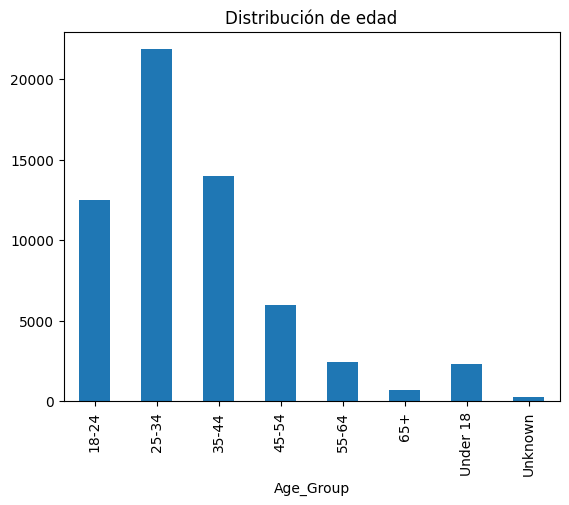

In [9]:
df['Age_Group'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Distribución de edad')
plt.show()

La distribución muestra alta concentración en edades tempranas. El grupo predominante es de 25-34 años, seguido por 34-44 años y 18-24 años, la concentracion empieza a disminuir progresivamente a partir de los 45 años.
La poblacion encuestada corresponde principalmente a fuerza laboral joven, caracteristica comun en el sector tecnologico por la rapida entrada al mercado y renovacion constante de perfiles.

## Distribución por nivel de educación

In [10]:
df["EdLevel_Group"].value_counts(normalize=True)*100

EdLevel_Group
Undergraduate Degree    42.639738
Postgraduate Degree     29.759070
No Formal Degree        23.355367
Not specified            2.828885
Other                    1.416940
Name: proportion, dtype: float64

Se observa que el 70% de los encuestados cuentan con estudios superiores, principalmente licenciatura, sin embargo, un 22% trabaja sin titulo formal, lo que indica que el sector tecnologico tiene barreras de entrada maas flexibles comparada con otros sectores.
Esto sugiere que las habilidades tecnicas y experiencia practica tienen un peso relevante en la empleabilidad.

In [11]:
df['Country'].value_counts().sort_values(ascending = False).head(10)

Country
USA    10923
DEU     4891
IND     4092
GBR     3191
UKR     2644
FRA     2096
CAN     2064
POL     1519
NLD     1434
BRA     1347
Name: count, dtype: int64

In [12]:
df['Country'].nunique()

182